#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> What is the average, median, and standard deviation of `Bill_Amount` per department?

> Detect outliers in `Bill_Amount` using the IQR method — which patients are outliers?

> Which hospital-department combination has the highest average length of stay?

> What is the total revenue and patient count per hospital per department? (3-level groupby)

> Are there any departments where average bill amount exceeds ₹15,000? Flag them as `'High Cost'`, else `'Normal'`.

In [2]:
# Hospital operations data — 21 patient records
data = {
    'Patient_ID': ['P001','P002','P003','P004','P005','P006','P007',
                   'P008','P009','P010','P011','P012','P013','P014',
                   'P015','P016','P017','P018','P019','P020','P021'],

    'Hospital': ['H1','H1','H1','H1','H1','H1','H1',
                 'H2','H2','H2','H2','H2','H2','H2',
                 'H3','H3','H3','H3','H3','H3','H3'],

    'Department': ['Cardiology','Cardiology','Orthopedics','Orthopedics',
                   'General','General','Neurology',
                   'Cardiology','Cardiology','Orthopedics','Orthopedics',
                   'General','General','Neurology',
                   'Cardiology','Cardiology','Orthopedics','Orthopedics',
                   'General','General','Neurology'],

    'Doctor_ID': ['D01','D02','D01','D03','D04','D04','D05',
                  'D01','D02','D03','D03','D04','D05','D05',
                  'D02','D01','D03','D03','D04','D05','D02'],

    'Length_of_Stay': [5, 3, 7, 4, 2, 3, 8,
                       6, 4, 5, 6, 1, 2, 9,
                       4, 6, 8, 3, 2, 4, 7],

    'Bill_Amount': [18000, 12000, 22000, 15000, 8000, 9000, 35000,
                    20000, 14000, 18000, 19000, 7000, 8500, 38000,
                    16000, 21000, 24000, 13000, 7500, 9500, 32000]
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Create DataFrame from hospital operations data
data_frame = pd.DataFrame(data)

data_frame

,Patient_ID,Hospital,Department,Doctor_ID,Length_of_Stay,Bill_Amount
0,P001,H1,Cardiology,D01,5,18000
1,P002,H1,Cardiology,D02,3,12000
2,P003,H1,Orthopedics,D01,7,22000
3,P004,H1,Orthopedics,D03,4,15000
4,P005,H1,General,D04,2,8000
5,P006,H1,General,D04,3,9000
6,P007,H1,Neurology,D05,8,35000
7,P008,H2,Cardiology,D01,6,20000
8,P009,H2,Cardiology,D02,4,14000
9,P010,H2,Orthopedics,D03,5,18000


#### `Step 2 :- Statistical Summary per Department`

In [4]:
# Calculate average, median, and std deviation of Bill_Amount per department
department_statistical = data_frame.groupby('Department')['Bill_Amount'].agg(Average = 'mean', Median = 'median', Standard_Deviation = 'std').round(2)

department_statistical

,Average,Median,Standard_Deviation
Department,,,
Cardiology,16833.33,17000.0,3488.07
General,8250.00,8250.0,935.41
Neurology,35000.00,35000.0,3000.00
Orthopedics,18500.00,18500.0,4135.21


#### `Step 3 :- IQR Outlier Detection`

In [5]:
# Calculate Q1, Q3, IQR and bounds for outlier detection
Q1 = data_frame['Bill_Amount'].quantile(0.25)

Q3 = data_frame['Bill_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [6]:
# Identify patients with Bill_Amount outside bounds
outliers = data_frame[(data_frame['Bill_Amount'] < lower_bound) | (data_frame['Bill_Amount'] > upper_bound)]

outliers

,Patient_ID,Hospital,Department,Doctor_ID,Length_of_Stay,Bill_Amount


In [7]:
# Print full working for transparency
print(f'Q1 = {Q1}')

print(f'Q3 = {Q3}')

print(f'IQR = {IQR}')

print(f'Lower Bound = {lower_bound}')

print(f'Upper Bound = {upper_bound}')

Q1 = 9500.0
Q3 = 21000.0
IQR = 11500.0
Lower Bound = -7750.0
Upper Bound = 38250.0


#### `Step 4 :- Hospital-Department Avg Length of Stay`

In [8]:
# Group by hospital and department, calculate mean length of stay
hospital_department_stay = data_frame.groupby(['Hospital', 'Department'])['Length_of_Stay'].mean().round(2).sort_values(ascending = False)

hospital_department_stay

Hospital  Department 
H2        Neurology      9.0
H1        Neurology      8.0
H3        Neurology      7.0
H1        Orthopedics    5.5
H3        Orthopedics    5.5
H2        Orthopedics    5.5
H3        Cardiology     5.0
H2        Cardiology     5.0
H1        Cardiology     4.0
H3        General        3.0
H1        General        2.5
H2        General        1.5
Name: Length_of_Stay, dtype: float64

#### `Step 5 :- 3-level Groupby (Revenue & Patient Count)`

In [9]:
# Group by hospital and department, calculate total revenue and patient count
hospital_department_summary = data_frame.groupby(['Hospital', 'Department']).agg(Total_Revenue = ('Bill_Amount', 'sum'), Patiend_Count = ('Patient_ID', 'count')).reset_index()

hospital_department_summary

,Hospital,Department,Total_Revenue,Patiend_Count
0,H1,Cardiology,30000,2
1,H1,General,17000,2
2,H1,Neurology,35000,1
3,H1,Orthopedics,37000,2
4,H2,Cardiology,34000,2
5,H2,General,15500,2
6,H2,Neurology,38000,1
7,H2,Orthopedics,37000,2
8,H3,Cardiology,37000,2
9,H3,General,17000,2


#### `Step 6 :- Cost Flag per Department`

In [10]:
# Flag departments as High Cost if avg bill > 15000, else Normal
department_average = data_frame.groupby('Department')['Bill_Amount'].mean()

department_flag_series = pd.Series(np.where(department_average > 15000, 'High Cost', 'Normal'), index = department_average.index)

data_frame['Cost_Flag'] = data_frame['Department'].map(department_flag_series)

data_frame

,Patient_ID,Hospital,Department,Doctor_ID,Length_of_Stay,Bill_Amount,Cost_Flag
0,P001,H1,Cardiology,D01,5,18000,High Cost
1,P002,H1,Cardiology,D02,3,12000,High Cost
2,P003,H1,Orthopedics,D01,7,22000,High Cost
3,P004,H1,Orthopedics,D03,4,15000,High Cost
4,P005,H1,General,D04,2,8000,Normal
5,P006,H1,General,D04,3,9000,Normal
6,P007,H1,Neurology,D05,8,35000,High Cost
7,P008,H2,Cardiology,D01,6,20000,High Cost
8,P009,H2,Cardiology,D02,4,14000,High Cost
9,P010,H2,Orthopedics,D03,5,18000,High Cost


#### `Step 7 :- Subplots Dashboard`

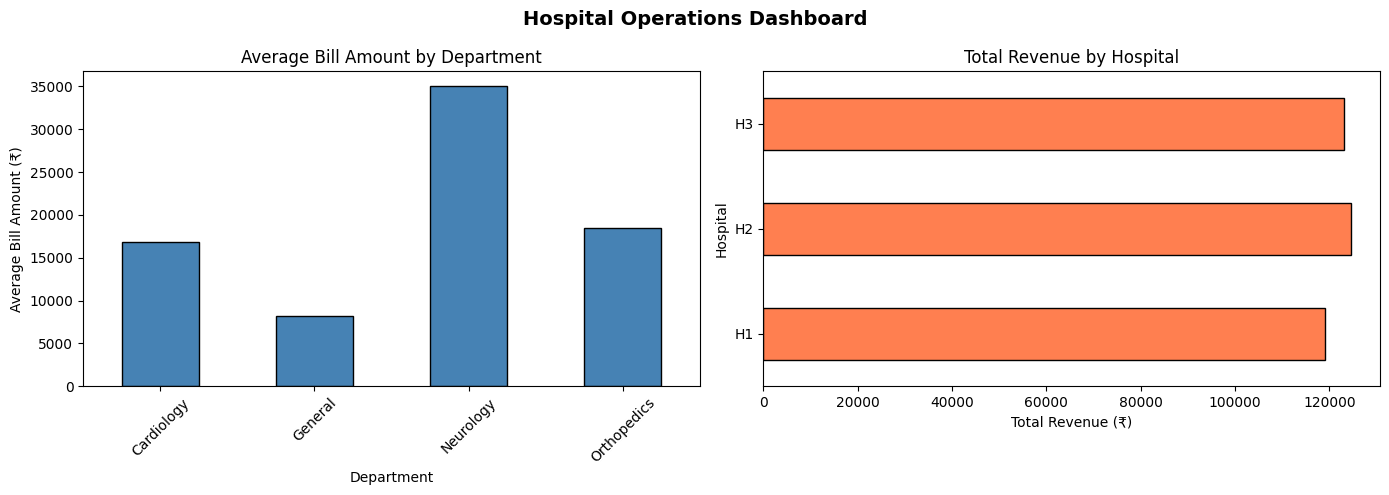

In [11]:
# Create two charts side by side: Avg Bill by Department and Total Revenue by Hospital
figure, (department_axis, hospital_revenue_axis) = plt.subplots(1, 2, figsize = (14, 5))

# Chart 1 — Avg Bill Amount by Department
department_statistical['Average'].plot(kind = 'bar', ax = department_axis, color ='steelblue', edgecolor = 'black')

department_axis.set_title('Average Bill Amount by Department')

department_axis.set_xlabel('Department')

department_axis.set_ylabel('Average Bill Amount (₹)')

department_axis.tick_params(axis = 'x', rotation = 45)

# Chart 2 — Total Revenue by Hospital
hospital_revenue = data_frame.groupby('Hospital')['Bill_Amount'].sum()

hospital_revenue.plot(kind = 'barh', ax = hospital_revenue_axis, color = 'coral', edgecolor = 'black')

hospital_revenue_axis.set_title('Total Revenue by Hospital')

hospital_revenue_axis.set_xlabel('Total Revenue (₹)')

hospital_revenue_axis.set_ylabel('Hospital')

plt.suptitle('Hospital Operations Dashboard', fontsize = 14, fontweight = 'bold')

plt.tight_layout()

plt.savefig('7_Insights_Hospital_Dashboard.png')

plt.show()

#### `Step 8 :- Print Outputs`

In [12]:
# Display all computed results clearly
print(f'\nDepartment Stats:\n{department_statistical}')

print(f'\nIQR Bounds:\nLower Bound = {lower_bound}\nUpper Bound = {upper_bound}')

print(f'\nOutliers:\n{outliers[['Patient_ID', 'Bill_Amount']]}')

print(f'\nHospital-Department Avg Length of Stay:\n{hospital_department_stay}')

print(f'\nHospital-Department Summary:\n{hospital_department_summary}')

print(f'\nCost Flag Counts:\n{data_frame['Cost_Flag'].value_counts()}')


Department Stats:
              Average   Median  Standard_Deviation
Department                                        
Cardiology   16833.33  17000.0             3488.07
General       8250.00   8250.0              935.41
Neurology    35000.00  35000.0             3000.00
Orthopedics  18500.00  18500.0             4135.21

IQR Bounds:
Lower Bound = -7750.0
Upper Bound = 38250.0

Outliers:
Empty DataFrame
Columns: [Patient_ID, Bill_Amount]
Index: []

Hospital-Department Avg Length of Stay:
Hospital  Department 
H2        Neurology      9.0
H1        Neurology      8.0
H3        Neurology      7.0
H1        Orthopedics    5.5
H3        Orthopedics    5.5
H2        Orthopedics    5.5
H3        Cardiology     5.0
H2        Cardiology     5.0
H1        Cardiology     4.0
H3        General        3.0
H1        General        2.5
H2        General        1.5
Name: Length_of_Stay, dtype: float64

Hospital-Department Summary:
   Hospital   Department  Total_Revenue  Patiend_Count
0        H1  

#### `Information`
> Rows: 21

> Columns: 7 (Patient_ID, Hospital, Department, Doctor_ID, Length_of_Stay, Bill_Amount, Cost_Flag)

> No missing values

> Outlier detection via IQR method

> Cost flag threshold: Avg Bill > ₹15,000 → High Cost

#### `Data Insights`
> Cardiology avg bill = ₹16,833.33 → High Cost

> Orthopedics avg bill = ₹18,500 → High Cost

> General avg bill = ₹8,250 → Normal

> Neurology avg bill = ₹35,000 → High Cost

> IQR outlier detection found 0 statistical outliers. Upper bound = ₹38,250. P014 (₹38,000) is close but inside bounds.

> Highest avg length of stay = H2‑Neurology = 9.0 days

> Total revenue: H1 = ₹1,19,000, H2 = ₹1,26,500, H3 = ₹1,12,500

#### `Business Insights`
> Neurology bills are 4× General → major cost driver even without statistical outliers.

> H2‑Neurology has longest stays (9 days) → capacity strain.

> Revenue distribution: H2 leads, H1 and H3 are close (₹6,500 gap) → relatively balanced.

> Cost flags show 3 out of 4 departments are High Cost.

#### `Risks`
> High cost departments may trigger patient dissatisfaction.

> Long stays increase bed occupancy → operational bottlenecks.

> Neurology billing variance may raise audit concerns.

#### `Opportunities`
> Optimize Neurology and Orthopedics stay durations.

> Review Neurology billing practices with CFO.

> Balance patient load across hospitals.

> Introduce cost control in Cardiology & Orthopedics.

#### `Recommendations`
> Review Neurology billing (avg ₹35,000) with CFO — not a statistical outlier but 4× General.

> Reduce H2‑Neurology stay duration → target <7 days.

> Balance patient allocation across hospitals.

> Flag Neurology, Cardiology, Orthopedics as High Cost → CFO to review.

#### `Expected Business Impact`
> Cost savings from reduced stay durations.

> Improved patient satisfaction from fair billing.

> Balanced hospital load → efficient resource use.

> Stronger compliance → protect hospital reputation.

#### `Future Prediction`
> If cost controls applied, avg bill in Cardiology & Orthopedics will drop below ₹15k.

> Neurology will remain high cost unless billing reforms introduced.

> Patient load balancing will stabilize revenues across hospitals.